In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

import sys
sys.path.append("..")

from utils.preprocessing import preprocessing_completo
from utils.config import PATH_RAD_MUNICIPIOS, PATH_PIB_MONTERREY

_,_,mont_rad_pib = preprocessing_completo("monterrey", path_radianza = PATH_RAD_MUNICIPIOS, path_pib = PATH_PIB_MONTERREY)
mont_rad_pib["log_pib_mun_trend"] = np.log(mont_rad_pib["pib_mun_trend"])

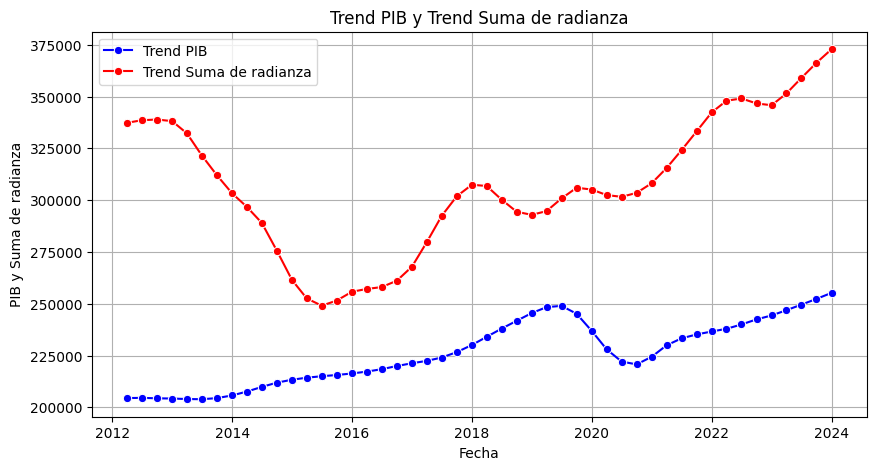

In [42]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="fecha", y="pib_mun_trend", data=mont_rad_pib, color = "blue", label = "Trend PIB", marker = "o")
sns.lineplot(x="fecha", y="Suma_de_radianza_trend_mean", data=mont_rad_pib, color = "red", label = "Trend Suma de radianza", marker = "o")
plt.legend()
plt.title("Trend PIB y Trend Suma de radianza")
plt.ylabel("PIB y Suma de radianza")
plt.xlabel("Fecha")
plt.grid(True)
plt.show()


In [43]:
mont_rad_pib.head(3)

,quarter,total_pixeles_median,Suma_de_radianza_trend_sum,Suma_de_radianza_trend_median,Suma_de_radianza_trend_std,Suma_de_radianza_trend_mean,Media_de_radianza_trend_sum,Media_de_radianza_trend_median,Media_de_radianza_trend_std,Media_de_radianza_trend_mean,...,Percentil_50_de_radianza_trend_mean,Percentil_75_de_radianza_trend_sum,Percentil_75_de_radianza_trend_median,Percentil_75_de_radianza_trend_std,Percentil_75_de_radianza_trend_mean,fecha,municipio,pib_mun_desestacionalizado,pib_mun_trend,log_pib_mun_trend
0,2012Q1,944.0,2.260189e+07,337375.753472,451.067987,337341.631003,23942.679319,357.389569,0.477826,357.353423,...,371.544162,30698.324705,458.230642,0.414620,458.183951,2012-03-31,Monterrey,203192.860438,204466.270111,12.228158
1,2012Q2,944.0,3.047335e+07,338642.789166,259.887249,338592.733717,32281.086901,358.731768,0.275304,358.678743,...,373.011865,41317.046550,459.119113,0.099884,459.078295,2012-06-30,Monterrey,204988.836490,204568.792993,12.228660
2,2012Q3,944.0,3.118174e+07,338959.064239,66.057983,338931.904762,33031.499193,359.066805,0.069977,359.038035,...,373.418013,42191.409257,458.660823,0.350722,458.602275,2012-09-30,Monterrey,204827.521210,204352.360784,12.227601


/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.972e-05, tolerance: 1.425e-05
  model = cd_fast.enet_coordinate_descent(
/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/sklearn

Alpha óptimo: 3.282269295595783e-05

Coeficientes Lasso:
 total_pixeles_median                            0.000000
Suma_de_radianza_trend_sum                      1.453938
Suma_de_radianza_trend_median                   0.641969
Suma_de_radianza_trend_std                      0.048320
Suma_de_radianza_trend_mean                     0.000000
Media_de_radianza_trend_sum                     0.000000
Media_de_radianza_trend_median                  0.003051
Media_de_radianza_trend_std                     0.000002
Media_de_radianza_trend_mean                    0.000000
Desviacion_estandar_de_radianza_trend_sum      -0.194346
Desviacion_estandar_de_radianza_trend_median   -0.000000
Desviacion_estandar_de_radianza_trend_std      -0.000000
Desviacion_estandar_de_radianza_trend_mean     -0.212343
Maximo_de_radianza_trend_sum                   -0.000000
Maximo_de_radianza_trend_median                 0.052400
Maximo_de_radianza_trend_std                   -0.013228
Maximo_de_radianza_trend_mean 

/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.415e-05, tolerance: 1.376e-05
  model = cd_fast.enet_coordinate_descent(
/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.297e-05, tolerance: 1.376e-05
  model = cd_fast.enet_coordinate_descent(
/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not conv

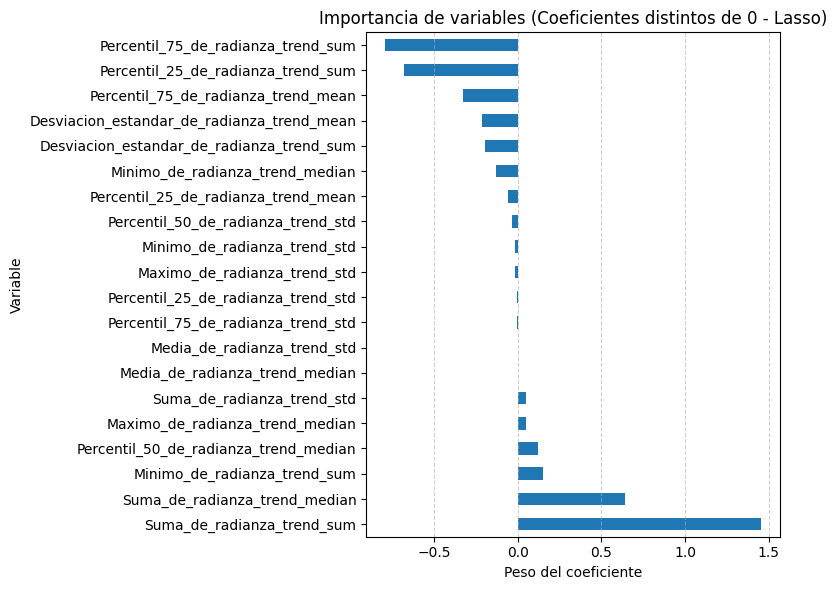

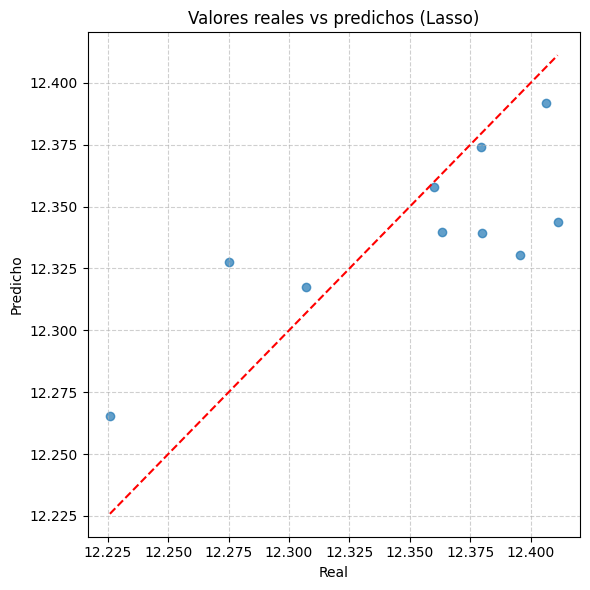

In [44]:
# Paso 1: importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Paso 2: definir X y y
X = mont_rad_pib.drop(columns=[
    "quarter", 
    "fecha", 
    "pib_mun_desestacionalizado", 
    "municipio", 
    "pib_mun_trend", 
    "log_pib_mun_trend"
])
y = mont_rad_pib["log_pib_mun_trend"]

# Paso 3: dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Paso 4: pipeline de estandarización + Lasso con CV
lasso_pipe = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=20000, n_alphas=200)
)

# Paso 5: entrenar el modelo
lasso_pipe.fit(X_train, y_train)

# Extraer el modelo entrenado
lasso_model = lasso_pipe.named_steps['lassocv']

# Paso 6: resultados del modelo
print("Alpha óptimo:", lasso_model.alpha_)

coef = pd.Series(lasso_model.coef_, index=X.columns)
importantes = coef[coef != 0].sort_values(ascending=False)

print("\nCoeficientes Lasso:\n", coef)
print("\nCaracterísticas más importantes:\n", importantes)

# Paso 7: métricas de rendimiento
y_pred = lasso_pipe.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR² en test: {r2:.4f}")
print(f"RMSE en test: {rmse:.4f}")

# Paso 8: visualización de importancia de variables
plt.figure(figsize=(8,6))
importantes.plot(kind='barh')
plt.title("Importancia de variables (Coeficientes distintos de 0 - Lasso)")
plt.xlabel("Peso del coeficiente")
plt.ylabel("Variable")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Paso 9 (opcional): comparar valores predichos vs reales
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Valores reales vs predichos (Lasso)")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:      log_pib_mun_trend   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     21.00
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           2.67e-09
Time:                        23:27:36   Log-Likelihood:                 143.77
No. Observations:                  48   AIC:                            -229.5
Df Residuals:                      19   BIC:                            -175.3
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

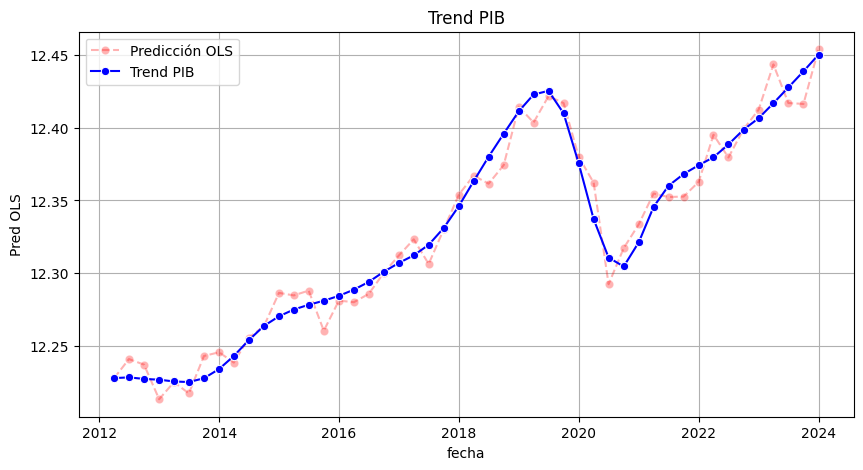

In [45]:
# Añadir una constante al modelo

X = mont_rad_pib.drop(columns = ["quarter", "fecha", "pib_mun_desestacionalizado", "municipio", "pib_mun_trend", "log_pib_mun_trend"])
y = mont_rad_pib["log_pib_mun_trend"]

X = sm.add_constant(X)
modelo = sm.OLS(y, X)
resultado = modelo.fit()

print(resultado.summary())

mont_rad_pib["Pred OLS"] = resultado.predict(X)

plt.figure(figsize=(10, 5))
sns.lineplot(x="fecha", y="Pred OLS", data=mont_rad_pib, color = "red", label = "Predicción OLS", marker = "o", linestyle = "--", alpha = 0.3)
sns.lineplot(x="fecha", y="log_pib_mun_trend", data=mont_rad_pib, color = "blue", label = "Trend PIB", marker = "o")
plt.legend()
plt.title("Trend PIB")
plt.grid(True)
plt.show()



# TODO:
- Revisar Supuestos OLS
- Probar OLS, RF, SVM y XGBoost
- Probar mismos modelos con dimensión de tiempo
- Pobar mismos modelos con lags